# Snake Species Classifier Evaluation and Performance Analysis

## 1. Import & Config

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast
from torch.utils.data import DataLoader

from PIL import ImageOps
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode

import timm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tqdm.auto import tqdm

In [2]:
DATA_ROOT = Path("/kaggle/input/datasets/lthhnglam/vn-snakeclef2023-crop/VN-SnakeCLEF2023-CROP")
MODEL_CKPT = Path("/kaggle/input/datasets/lthhnglam/2-convnextv2-finetuned-safeloss/convnextv2_base_arcface_safety_best.pt")
CLASSES_CSV = Path("/kaggle/input/datasets/lthhnglam/vn-snakeclef2023-crop/VN-SnakeCLEF2023-CROP/classes.csv")

TEST_DIR = DATA_ROOT / "test"
VAL_DIR = DATA_ROOT / "val"

IMG_SIZE = 384
BATCH_SIZE = 18

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Load Dataset

In [3]:
class PadToSquare:
    def __call__(self, image):
        w, h = image.size
        size = max(w, h)
        pad_w, pad_h = size - w, size - h
        padding = (pad_w // 2, pad_h // 2, pad_w - pad_w // 2, pad_h - pad_h // 2)
        return ImageOps.expand(image, padding, fill=(124, 116, 104))

transform_method = transforms.Compose([
    PadToSquare(),
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform_method)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform_method)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=1, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=1, pin_memory=True)

NUM_VAL_CLASSES = len(val_dataset.classes)
NUM_TEST_CLASSES = len(test_dataset.classes)

print(f"Validation images : {len(val_dataset)} | Batches: {len(val_loader)}")
print(f"Test images       : {len(test_dataset)} | Batches: {len(test_loader)}")
print(f"Validation classes: {NUM_VAL_CLASSES}")
print(f"Test classes      : {NUM_TEST_CLASSES}")

Validation images : 2081 | Batches: 116
Test images       : 1643 | Batches: 92
Validation classes: 109
Test classes      : 107


In [4]:
classes_df = pd.read_csv(CLASSES_CSV).sort_values("label_idx").reset_index(drop=True)
mivs_map = dict(zip(classes_df["label_idx"], classes_df["MIVS"]))

print(f"Classes          : {len(classes_df)}")
print(f"Venomous classes : {(classes_df['MIVS'] == 1).sum()}")
print(f"Harmless classes : {(classes_df['MIVS'] == 0).sum()}")

Classes          : 109
Venomous classes : 22
Harmless classes : 87


## 3. Load Model After Training

In [5]:
class ArcFace(nn.Module):
    def __init__(self, in_features, num_classes, scale=30.0, margin=0.3):
        super().__init__()
        self.scale, self.margin = scale, margin
        self.weight = nn.Parameter(torch.empty(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, features, labels=None):
        cosine = F.linear(F.normalize(features), F.normalize(self.weight))
        cosine = cosine.clamp(-1 + 1e-7, 1 - 1e-7)
        if labels is None:
            return cosine * self.scale
        theta = torch.acos(cosine)
        target_cosine = torch.cos(theta + self.margin)
        one_hot = F.one_hot(labels, num_classes=cosine.size(1)).float()
        logits = cosine * (1 - one_hot) + target_cosine * one_hot
        return logits * self.scale

In [6]:
model = timm.create_model("convnextv2_base.fcmae_ft_in22k_in1k_384", pretrained=False, num_classes=0, drop_path_rate=0.2)
arcface = ArcFace(in_features=model.num_features, num_classes=NUM_VAL_CLASSES, scale=30.0, margin=0.3)

checkpoint = torch.load(MODEL_CKPT, map_location="cpu", weights_only=True)
model.load_state_dict(checkpoint["model"], strict=True)
arcface.load_state_dict(checkpoint["arcface"], strict=True)

model = model.to(DEVICE).eval()
arcface = arcface.to(DEVICE).eval()

num_params = sum(p.numel() for p in model.parameters())

print(f"Parameters    : {num_params / 1e6:.2f}M")
print(f"Saved epoch   : {checkpoint['epoch']}")
print(f"Saved Val Acc : {checkpoint['val_acc']:.4f}")

Parameters    : 87.69M
Saved epoch   : 12
Saved Val Acc : 0.8313


## 4. Overview Evaluation

In [7]:
def build_label_map(source_dataset, reference_dataset):
    label_map = {source_dataset.class_to_idx[name]: reference_dataset.class_to_idx[name] for name in source_dataset.classes}
    missing_classes = sorted(set(reference_dataset.classes) - set(source_dataset.classes))

    print(f"Mapped classes : {len(label_map)}")
    print(f"Missing classes: {missing_classes}")

    return label_map

def evaluate(model, arcface, loader, criterion=None, label_map=None, topk=(1,)):
    model.eval()
    arcface.eval()

    total = 0
    total_loss = 0.0
    correct = {k: 0 for k in topk}

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(DEVICE, non_blocking=True)

            if label_map is not None:
                labels = torch.tensor([label_map[int(x)] for x in labels], device=DEVICE)
            else:
                labels = labels.to(DEVICE, non_blocking=True)

            with autocast("cuda", enabled=DEVICE.type == "cuda"):
                features = model(images)
                logits = arcface(features)

                if criterion is not None:
                    loss = criterion(logits, labels)
                    total_loss += loss.item() * images.size(0)

            top_preds = logits.topk(max(topk), dim=1).indices

            for k in topk:
                correct[k] += (top_preds[:, :k] == labels.unsqueeze(1)).any(dim=1).sum().item()

            total += labels.size(0)

    results = {f"top{k}": correct[k] / total for k in topk}

    if criterion is not None:
        results["loss"] = total_loss / total

    return results

In [8]:
criterion = nn.CrossEntropyLoss()

test_to_model = build_label_map(test_dataset, val_dataset)

val_results = evaluate(model, arcface, val_loader, criterion=criterion, topk=(1,))
test_results = evaluate(model, arcface, test_loader, label_map=test_to_model, topk=(1, 3))

print(f"Val Loss     : {val_results['loss']:.4f}")
print(f"Val Top-1    : {val_results['top1']:.4f} ({val_results['top1']*100:.2f}%)")
print(f"Test Top-1   : {test_results['top1']:.4f} ({test_results['top1']*100:.2f}%)")
print(f"Test Top-3   : {test_results['top3']:.4f} ({test_results['top3']*100:.2f}%)")

Mapped classes : 107
Missing classes: ['002', '052']


  0%|          | 0/116 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

Val Loss     : 1.3636
Val Top-1    : 0.8313 (83.13%)
Test Top-1   : 0.8302 (83.02%)
Test Top-3   : 0.9209 (92.09%)


## 5. Details Evaluation

### Test Set Inference

In [9]:
def collect_predictions(model, arcface, loader, label_map=None):
    model.eval()
    arcface.eval()
    all_true, all_pred, all_conf = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(DEVICE, non_blocking=True)

            if label_map is not None:
                labels = torch.tensor([label_map[int(x)] for x in labels], device=DEVICE)
            else:
                labels = labels.to(DEVICE, non_blocking=True)

            with autocast("cuda", enabled=DEVICE.type == "cuda"):
                features = model(images)
                logits = arcface(features)

            probs = torch.softmax(logits, dim=1)
            conf, preds = probs.max(dim=1)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            all_conf.extend(conf.cpu().numpy())

    return np.array(all_true), np.array(all_pred), np.array(all_conf)

In [10]:
all_true, all_pred, all_conf = collect_predictions(model, arcface, test_loader, test_to_model)
print(f"Predictions collected: {len(all_true)}")

  0%|          | 0/92 [00:00<?, ?it/s]

Predictions collected: 1643


### Overall Classification Performance

In [11]:
present_labels = sorted(np.unique(all_true))

accuracy = accuracy_score(all_true, all_pred)
precision = precision_score(all_true, all_pred, labels=present_labels, average="macro", zero_division=0)
recall = recall_score(all_true, all_pred, labels=present_labels, average="macro", zero_division=0)
macro_f1 = f1_score(all_true, all_pred, labels=present_labels, average="macro", zero_division=0)

print(f"Accuracy        : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Macro Precision : {precision:.4f}")
print(f"Macro Recall    : {recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")

Accuracy        : 0.8302 (83.02%)
Macro Precision : 0.7801
Macro Recall    : 0.7875
Macro F1        : 0.7671


### Per-Class Performance Analysis

In [12]:
class_names = [val_dataset.classes[i] for i in present_labels]

report = classification_report(
    all_true, all_pred, labels=present_labels, target_names=class_names,
    output_dict=True, zero_division=0
)

per_class_df = pd.DataFrame(report).T.loc[class_names].sort_values("f1-score")

In [13]:
print("5 Worst Performing Classes")
display(per_class_df.head(5).round(3))

print("5 Best Performing Classes")
display(per_class_df.tail(5).sort_values("f1-score", ascending=False).round(3))

5 Worst Performing Classes


,precision,recall,f1-score,support
043,0.000,0.000,0.000,8.0
094,0.000,0.000,0.000,1.0
100,0.125,0.333,0.182,3.0
044,0.250,0.200,0.222,5.0
060,0.500,0.154,0.235,13.0


5 Best Performing Classes


,precision,recall,f1-score,support
020,1.0,1.0,1.0,20.0
007,1.0,1.0,1.0,5.0
089,1.0,1.0,1.0,10.0
077,1.0,1.0,1.0,4.0
072,1.0,1.0,1.0,3.0


### Confusion Matrix

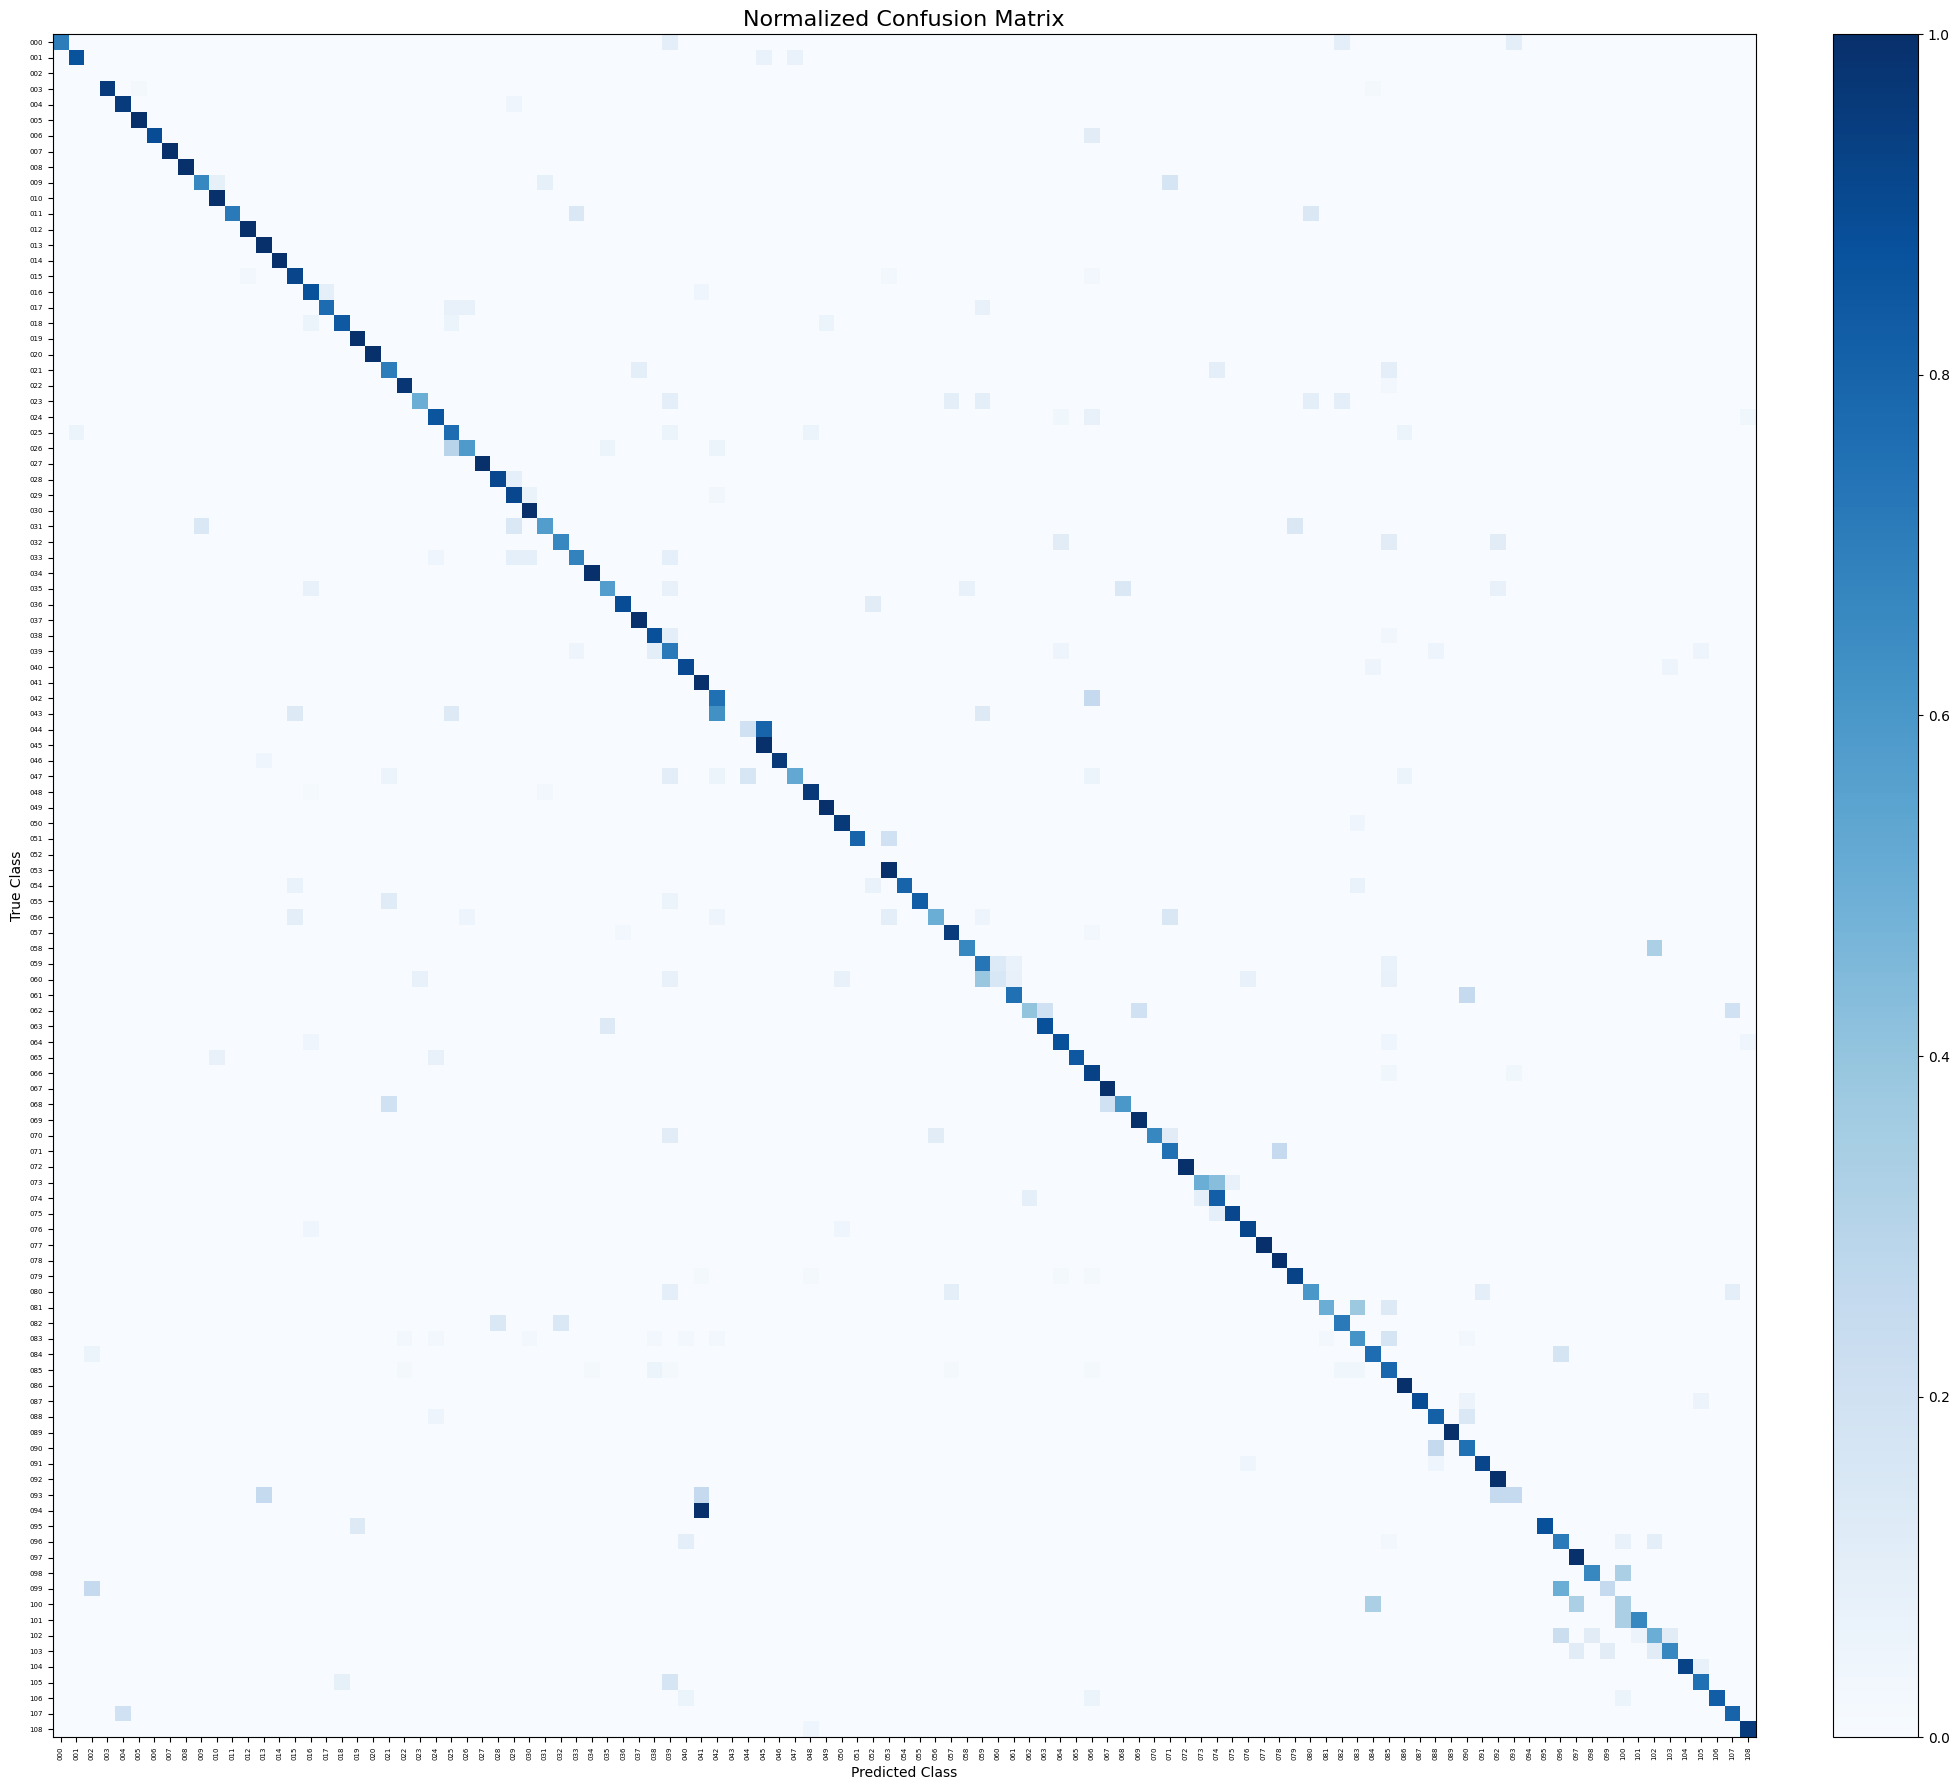

In [19]:
cm = confusion_matrix(all_true, all_pred, labels=range(NUM_VAL_CLASSES), normalize="true")

fig, ax = plt.subplots(figsize=(20, 18))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")

ax.set_title("Normalized Confusion Matrix", fontsize=16)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

ticks = np.arange(NUM_VAL_CLASSES)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(val_dataset.classes, rotation=90, fontsize=5)
ax.set_yticklabels(val_dataset.classes, fontsize=5)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Safety-Aware and SnakeCLEF Metrics

In [17]:
def compute_safety_metrics(y_true, y_pred, mivs_map):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)

    true_venom = np.array([mivs_map[int(x)] == 1 for x in y_true])
    pred_venom = np.array([mivs_map[int(x)] == 1 for x in y_pred])
    wrong = y_true != y_pred

    harmless_total = (~true_venom).sum()
    venomous_total = true_venom.sum()

    h_to_h = (wrong & ~true_venom & ~pred_venom).sum() / harmless_total * 100
    h_to_v = (wrong & ~true_venom & pred_venom).sum() / harmless_total * 100
    v_to_h = (wrong & true_venom & ~pred_venom).sum() / venomous_total * 100
    v_to_v = (wrong & true_venom & pred_venom).sum() / venomous_total * 100

    accuracy = accuracy_score(y_true, y_pred) * 100

    present_labels = np.unique(y_true)
    macro_f1_present = f1_score(y_true, y_pred, labels=present_labels, average="macro", zero_division=0) * 100
    macro_f1_official = f1_score(y_true, y_pred, average="macro", zero_division=0) * 100

    def track1(f1):
        return (f1 + (100-h_to_h) + 2*(100-h_to_v) + 5*(100-v_to_h) + 2*(100-v_to_v)) / 11

    return {
        "accuracy": accuracy,
        "macro_f1_present": macro_f1_present,
        "macro_f1_official": macro_f1_official,
        "h_to_h": h_to_h,
        "h_to_v": h_to_v,
        "v_to_h": v_to_h,
        "v_to_v": v_to_v,
        "track1_present": track1(macro_f1_present),
        "track1_official": track1(macro_f1_official),
        "harmless_samples": harmless_total,
        "venomous_samples": venomous_total
    }

In [18]:
results = compute_safety_metrics(all_true, all_pred, mivs_map)

print(f"Accuracy                  : {results['accuracy']:.2f}%")
print(f"Macro F1 (present classes): {results['macro_f1_present']:.2f}%")
print(f"Macro F1 (official style) : {results['macro_f1_official']:.2f}%")
print(f"Harmless -> Harmless      : {results['h_to_h']:.2f}%")
print(f"Harmless -> Venomous      : {results['h_to_v']:.2f}%")
print(f"Venomous -> Harmless      : {results['v_to_h']:.2f}%")
print(f"Venomous -> Venomous      : {results['v_to_v']:.2f}%")
print(f"Track 1 (present classes) : {results['track1_present']:.2f}")
print(f"Track 1 (official style)  : {results['track1_official']:.2f}")

Accuracy                  : 83.02%
Macro F1 (present classes): 76.71%
Macro F1 (official style) : 75.31%
Harmless -> Harmless      : 14.62%
Harmless -> Venomous      : 1.98%
Venomous -> Harmless      : 7.58%
Venomous -> Venomous      : 10.91%
Track 1 (present classes) : 90.77
Track 1 (official style)  : 90.64
